# Phase 5 — Evaluation & Comparison

## Purpose
We run the final, definitive evaluation of all four models using the
**test set** — 2,250 images that no model has ever seen during training
or validation.

Validation accuracy (Phase 4) told us one number per model.
This phase tells us the full story:

- **Confusion matrix** — which classes get confused with which?
- **Precision** — of all times the model predicted class X, how often was it right?
- **Recall** — of all actual class X images, how many did the model catch?
- **F1-score** — harmonic mean of precision and recall
- **ROC curve & AUC** — how well does the model separate classes at all thresholds?

## Why recall matters most here
In medical imaging, a **false negative** (missing a cancer case) is far more
dangerous than a **false positive** (flagging a healthy patient for follow-up).
Recall measures exactly this — how many real cancer cases did the model catch?
We pay special attention to recall for `lung_aca` and `lung_scc`.

## How models are loaded
We use a rebuild + numpy strategy defined in `src/model_loader.py`:
1. Rebuild the exact architecture using the original build function
2. For transfer learning models: unfreeze last 30 layers to match Stage 2
3. Load saved `.npy` weight arrays directly with `model.set_weights()`

This bypasses all TF 2.10 serialization bugs completely.

## Output
All plots and reports are saved to `results/` for the final report.

## Step 1 — Imports

In [1]:
import os
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import sys
import numpy as np
import matplotlib.pyplot as plt
import itertools

# scikit-learn provides all evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)

# Add project root to path so we can import from src/
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import get_data_generators, IMG_SIZE, BATCH_SIZE

import tensorflow as tf

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.10.0
GPU        : True


## Step 2 — Load Test Generators

Each model requires its own test generator because each transfer learning
model expects a different pixel format:

- **Baseline CNN** — `rescale=True`, no preprocessing function
  → pixels normalized to [0, 1]

- **EfficientNetB0** — `rescale=False`, `eff_preprocess`
  → raw [0, 255] pixels passed to EfficientNet's internal normalization

- **InceptionV3** — `rescale=False`, `inc_preprocess`
  → raw pixels scaled to [-1, 1]

- **ResNet50** — `rescale=False`, `res_preprocess`
  → raw pixels with ImageNet channel means subtracted

All generators use `shuffle=False` — this guarantees that the order of
predictions matches the order of true labels when computing metrics.

In [2]:
# Model-specific preprocessing functions
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as res_preprocess

DATA_DIR = r"../data/lung_image_sets"

# ── Baseline CNN generator ────────────────────────────────────────────────
_, _, test_gen_baseline = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = True,
    preprocessing_function = None
)

# ── EfficientNetB0 generator ──────────────────────────────────────────────
_, _, test_gen_eff = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = eff_preprocess
)

# ── InceptionV3 generator ─────────────────────────────────────────────────
_, _, test_gen_inc = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = inc_preprocess
)

# ── ResNet50 generator ────────────────────────────────────────────────────
_, _, test_gen_res = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = res_preprocess
)

# Class configuration — consistent across all models
CLASS_LABELS = ["lung_aca", "lung_n", "lung_scc"]
CLASS_NAMES  = ["Lung Adenocarcinoma", "Normal", "Squamous Cell Carcinoma"]

print(f"Test samples (baseline) : {test_gen_baseline.n}")
print(f"Test samples (eff)      : {test_gen_eff.n}")
print(f"Test samples (inc)      : {test_gen_inc.n}")
print(f"Test samples (res)      : {test_gen_res.n}")

Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
───────────────────────────────────────────────────────
  Data Generators Ready
───────────────────────────────────────────────────────
  Image size             : 224 × 224 px
  Batch size             : 32
  Rescaling              : [0,1]
  Preprocessing function : None
  Train samples          : 10500
  Val   samples          : 2250
  Test  samples          : 2250
  Classes                : {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
───────────────────────────────────────────────────────
Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
───────────────────────────────────────────────────────
  Data Generators Ready
───────────────────────────────────────────────────────
 

## Step 3 — Load All Models

We load all four models using `src/model_loader.py`.

The loading strategy differs per model type:

**Baseline CNN:**
Loaded directly from `baseline_cnn_best.keras` — this format works
correctly for a simple fully-trained architecture with no partial freezing.

**Transfer learning models (EfficientNetB0, InceptionV3, ResNet50):**
Loaded using the rebuild + numpy strategy:
1. Rebuild the architecture from scratch (fully frozen)
2. Unfreeze last 30 layers to match the exact Stage 2 state the weights were saved from
3. Call `model.set_weights()` with arrays loaded from the `.npy` file

`importlib.reload` is called before importing to ensure the latest
version of `model_loader.py` is used, not a cached version from memory.

In [3]:
import importlib
import src.model_loader

# Force reload to ensure we use the latest version of model_loader.py
# and not a cached version from a previous kernel session
importlib.reload(src.model_loader)
from src.model_loader import load_all_models

print("Loading all models...\n")
all_models = load_all_models()

baseline_model  = all_models["baseline_cnn"]
effnet_model    = all_models["efficientnetb0"]
inception_model = all_models["inceptionv3"]
resnet_model    = all_models["resnet50"]

print("\n✅ All four models loaded successfully.")

Loading all models...


Loading baseline_cnn ...
  Building baseline_cnn architecture ...
  Loading weights from baseline_cnn_weights.npy ...
  ✅ baseline_cnn ready.

Loading efficientnetb0 ...
  Building efficientnetb0 architecture ...
  EfficientNetB0 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 312
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  EfficientNetB0 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 30
  Loading weights from efficientnetb0_weights.npy ...
  ✅ efficientnetb0 ready.

Loading inceptionv3 ...
  Building inceptionv3 architecture ...
  InceptionV3 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 376
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  InceptionV3 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 19
  Loading weights from inceptionv3_weights.npy ...
  ✅ inceptionv3 ready.

Loading res

## Step 4 — Generate Predictions

For each model we run `model.predict()` on the full test set and collect:

- `y_true` — the actual ground truth labels (integers: 0, 1, or 2)
- `y_pred` — the predicted class label (argmax of softmax output)
- `y_prob` — the raw softmax probabilities (needed for ROC curves)

`generator.reset()` is called before each prediction to ensure the
generator starts from the very first image. Without this, the generator
might start mid-way through the dataset and produce misaligned labels.

Each transfer learning model uses its own generator so the correct
preprocessing is applied before the images reach that model.

In [5]:
def get_predictions(model, generator):
    """
    Runs model inference on the full test set.

    Args:
        model     (tf.keras.Model)    : Trained model to evaluate.
        generator (DataFrameIterator) : Test generator with shuffle=False.

    Returns:
        tuple: (y_true, y_pred, y_prob)
            y_true (np.array): Ground truth class indices, shape (n,)
            y_pred (np.array): Predicted class indices, shape (n,)
            y_prob (np.array): Softmax probabilities, shape (n, 3)
    """
    # Reset to first image — critical for correct label alignment
    generator.reset()

    # steps + 1 ensures we cover all images even if n is not divisible by batch_size
    y_prob = model.predict(
        generator,
        steps   = generator.n // BATCH_SIZE + 1,
        verbose = 1
    )

    # Trim to exact dataset size — the +1 step may produce a few extra predictions
    y_prob = y_prob[:generator.n]

    # Highest probability → predicted class index
    y_pred = np.argmax(y_prob, axis=1)

    # generator.classes gives the integer label for every image in order
    y_true = np.array(generator.classes[:generator.n])

    return y_true, y_pred, y_prob


print("Generating predictions — Baseline CNN ...")
y_true_base, y_pred_base, y_prob_base = get_predictions(
    baseline_model, test_gen_baseline
)

print("\nGenerating predictions — EfficientNetB0 ...")
y_true_eff, y_pred_eff, y_prob_eff = get_predictions(
    effnet_model, test_gen_eff
)

print("\nGenerating predictions — InceptionV3 ...")
y_true_inc, y_pred_inc, y_prob_inc = get_predictions(
    inception_model, test_gen_inc
)

print("\nGenerating predictions — ResNet50 ...")
y_true_res, y_pred_res, y_prob_res = get_predictions(
    resnet_model, test_gen_res
)

print("\n✅ All predictions generated.")
print(f"   Prediction array shape : {y_prob_base.shape}")  # expected (2250, 3)
print(f"   True label shape       : {y_true_base.shape}")  # expected (2250,)

Generating predictions — Baseline CNN ...
71/71 [==============================] - 16s 219ms/step

Generating predictions — EfficientNetB0 ...
71/71 [==============================] - 16s 223ms/step

Generating predictions — InceptionV3 ...
71/71 [==============================] - 15s 217ms/step

Generating predictions — ResNet50 ...
71/71 [==============================] - 18s 253ms/step

✅ All predictions generated.
   Prediction array shape : (2250, 3)
   True label shape       : (2250,)


## Step 5 — Confusion Matrices

A confusion matrix is a table where:
- **Rows** represent the actual (true) class
- **Columns** represent the predicted class
- **Diagonal cells** are correct predictions
- **Off-diagonal cells** are mistakes — they tell us which class
  was confused with which

We normalize each row by the total number of images in that class
so each cell shows a **percentage** — easier to read than raw counts.

For example, a value of 2.5% in row `lung_aca`, column `lung_scc`
means 2.5% of adenocarcinoma images were misclassified as squamous
cell carcinoma.

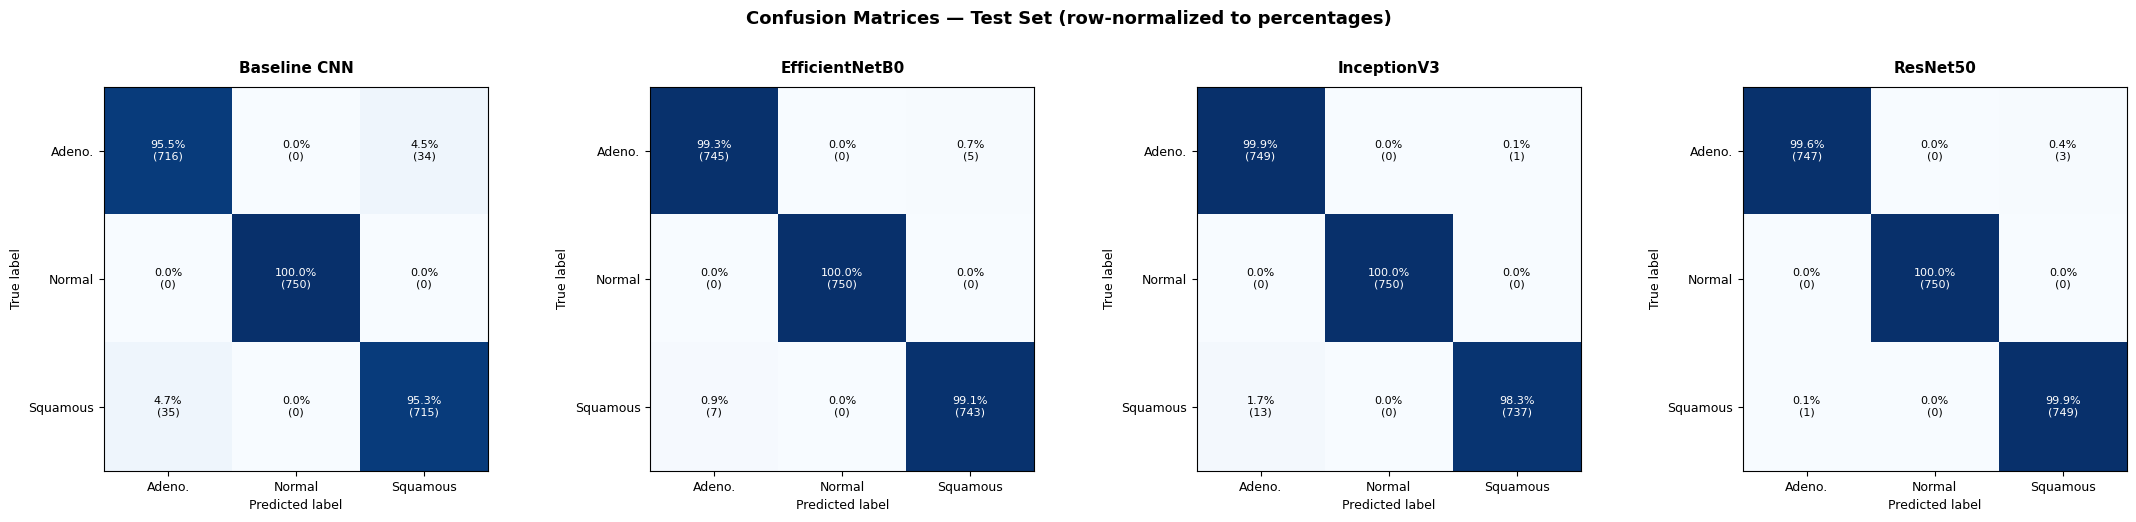

💾 Saved → results/confusion_matrices.png


In [6]:
def plot_confusion_matrix(y_true, y_pred, class_names, model_name, ax):
    """
    Plots a normalized confusion matrix on a given matplotlib axis.

    Args:
        y_true      (np.array): Ground truth labels.
        y_pred      (np.array): Predicted labels.
        class_names (list)    : Full display names for each class.
        model_name  (str)     : Title label for the plot.
        ax          (Axes)    : Matplotlib axis to draw on.
    """
    cm = confusion_matrix(y_true, y_pred)

    # Normalize each row → percentages (each row sums to 100%)
    cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

    ax.imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    ax.set_title(model_name, fontsize=11, fontweight="bold", pad=10)

    # Shorter tick labels to avoid overlap
    short = ["Adeno.", "Normal", "Squamous"]
    ticks = range(len(short))
    ax.set_xticks(ticks); ax.set_xticklabels(short, fontsize=9)
    ax.set_yticks(ticks); ax.set_yticklabels(short, fontsize=9)
    ax.set_ylabel("True label",      fontsize=9)
    ax.set_xlabel("Predicted label", fontsize=9)

    # Annotate each cell — white text on dark cells, black on light cells
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "white" if cm_pct[i, j] > 50 else "black"
        ax.text(
            j, i,
            f"{cm_pct[i, j]:.1f}%\n({cm[i, j]})",
            ha="center", va="center",
            fontsize=8, color=color
        )


fig, axes = plt.subplots(1, 4, figsize=(22, 5))

plot_confusion_matrix(y_true_base, y_pred_base, CLASS_NAMES, "Baseline CNN",   axes[0])
plot_confusion_matrix(y_true_eff,  y_pred_eff,  CLASS_NAMES, "EfficientNetB0", axes[1])
plot_confusion_matrix(y_true_inc,  y_pred_inc,  CLASS_NAMES, "InceptionV3",    axes[2])
plot_confusion_matrix(y_true_res,  y_pred_res,  CLASS_NAMES, "ResNet50",       axes[3])

plt.suptitle(
    "Confusion Matrices — Test Set (row-normalized to percentages)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/confusion_matrices.png")

## Step 6 — Classification Report

The classification report gives us per-class metrics for each model:

- **Precision** — of all images predicted as class X, what fraction
  were actually class X?
  Formula: TP / (TP + FP)

- **Recall (Sensitivity)** — of all images that truly belong to class X,
  what fraction did the model correctly catch?
  Formula: TP / (TP + FN)
  → Most critical in medical imaging. A missed cancer = false negative.

- **F1-score** — harmonic mean of precision and recall.
  Penalizes models that are strong in one but weak in the other.
  Formula: 2 × (Precision × Recall) / (Precision + Recall)

- **Support** — number of test images per class (expected ~750 each)

**Macro average** — unweighted mean across all classes.
  Since our dataset is balanced, macro and weighted averages will be equal.

In [7]:
models_eval = [
    ("Baseline CNN",   y_true_base, y_pred_base),
    ("EfficientNetB0", y_true_eff,  y_pred_eff),
    ("InceptionV3",    y_true_inc,  y_pred_inc),
    ("ResNet50",       y_true_res,  y_pred_res),
]

for model_name, y_true, y_pred in models_eval:
    print("=" * 62)
    print(f"  {model_name}")
    print("=" * 62)
    print(classification_report(
        y_true,
        y_pred,
        target_names = CLASS_NAMES,
        digits       = 4
    ))

  Baseline CNN
                         precision    recall  f1-score   support

    Lung Adenocarcinoma     0.9534    0.9547    0.9540       750
                 Normal     1.0000    1.0000    1.0000       750
Squamous Cell Carcinoma     0.9546    0.9533    0.9540       750

               accuracy                         0.9693      2250
              macro avg     0.9693    0.9693    0.9693      2250
           weighted avg     0.9693    0.9693    0.9693      2250

  EfficientNetB0
                         precision    recall  f1-score   support

    Lung Adenocarcinoma     0.9907    0.9933    0.9920       750
                 Normal     1.0000    1.0000    1.0000       750
Squamous Cell Carcinoma     0.9933    0.9907    0.9920       750

               accuracy                         0.9947      2250
              macro avg     0.9947    0.9947    0.9947      2250
           weighted avg     0.9947    0.9947    0.9947      2250

  InceptionV3
                         precision    

## Step 7 — ROC Curves

A **ROC curve** (Receiver Operating Characteristic) plots:
- **True Positive Rate (Recall)** on the y-axis
- **False Positive Rate** on the x-axis

For our 3-class problem we use the **One-vs-Rest** strategy:
for each class, we treat it as the "positive" class and all others
as "negative", then plot one ROC curve for that class.

**AUC (Area Under the Curve):**
- AUC = 1.0 → perfect separation
- AUC = 0.5 → random guessing (the diagonal dashed line)
- AUC > 0.99 is considered outstanding for medical imaging

A curve that hugs the top-left corner is ideal — high recall
while maintaining a low false positive rate.

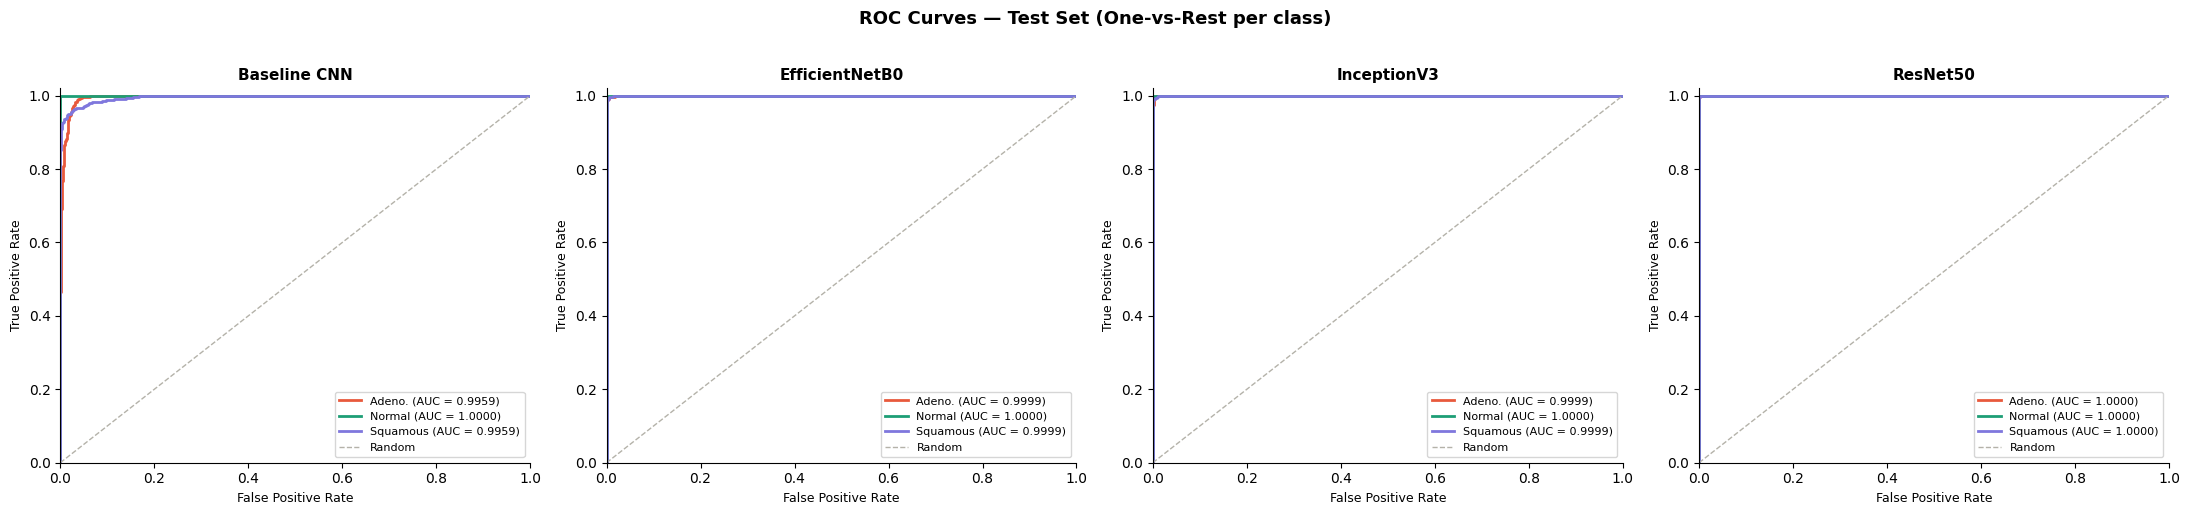

💾 Saved → results/roc_curves.png


In [8]:
def plot_roc_curves(y_true, y_prob, class_names, model_name, ax):
    """
    Plots One-vs-Rest ROC curves for all three classes on one axis.

    Args:
        y_true      (np.array): Ground truth labels, shape (n,).
        y_prob      (np.array): Softmax probabilities, shape (n, 3).
        class_names (list)    : Display names for each class.
        model_name  (str)     : Title label.
        ax          (Axes)    : Matplotlib axis to draw on.
    """
    colors     = ["#E8593C", "#1D9E75", "#7F77DD"]
    short_names = ["Adeno.", "Normal", "Squamous"]

    for i, (short, color) in enumerate(zip(short_names, colors)):
        # Binarize labels: class i = 1, all others = 0
        y_binary = (y_true == i).astype(int)
        y_score  = y_prob[:, i]

        fpr, tpr, _ = roc_curve(y_binary, y_score)
        roc_auc     = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{short} (AUC = {roc_auc:.4f})")

    # Diagonal = random classifier
    ax.plot([0, 1], [0, 1], color="#B4B2A9",
            linewidth=1, linestyle="--", label="Random")

    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])


fig, axes = plt.subplots(1, 4, figsize=(22, 5))

plot_roc_curves(y_true_base, y_prob_base, CLASS_NAMES, "Baseline CNN",   axes[0])
plot_roc_curves(y_true_eff,  y_prob_eff,  CLASS_NAMES, "EfficientNetB0", axes[1])
plot_roc_curves(y_true_inc,  y_prob_inc,  CLASS_NAMES, "InceptionV3",    axes[2])
plot_roc_curves(y_true_res,  y_prob_res,  CLASS_NAMES, "ResNet50",       axes[3])

plt.suptitle(
    "ROC Curves — Test Set (One-vs-Rest per class)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../results/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/roc_curves.png")

## Step 8 — Final Comparison Table

We consolidate accuracy, F1-score, and mean AUC into one table.
This is the definitive result of the project — computed on the test
set which no model ever saw during training or validation.

**Test accuracy vs validation accuracy:**
Validation accuracy was used during training to monitor progress.
Test accuracy is the unbiased estimate of real-world performance —
it is always the number reported in the final project report.

  FINAL EVALUATION — TEST SET
  Model                  Accuracy   F1 (macro)   Mean AUC
--------------------------------------------------------------------
  Baseline CNN             96.93%       96.93%     0.9973
  EfficientNetB0           99.47%       99.47%     0.9999
  InceptionV3              99.38%       99.38%     0.9999
  ResNet50                 99.82%       99.82%     1.0000  ← best


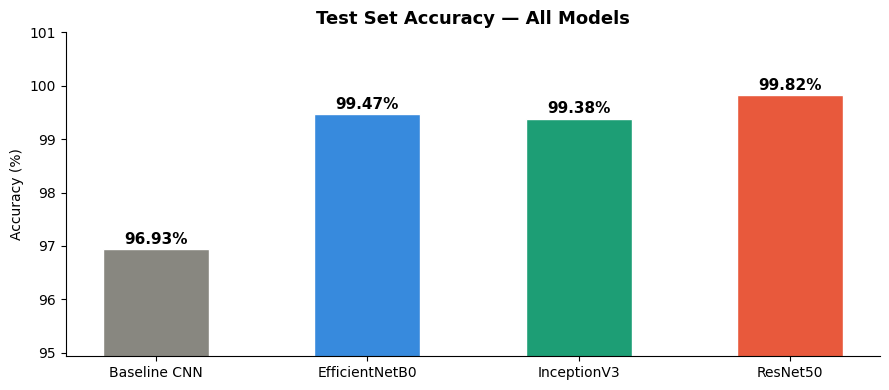

💾 Saved → results/final_test_accuracy_comparison.png


In [9]:
def compute_summary(y_true, y_pred, y_prob):
    """
    Computes key evaluation metrics for one model.

    Args:
        y_true (np.array): Ground truth labels.
        y_pred (np.array): Predicted labels.
        y_prob (np.array): Softmax probabilities, shape (n, 3).

    Returns:
        dict: accuracy, macro F1, and mean AUC.
    """
    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")

    # AUC per class → then average
    aucs = []
    for i in range(y_prob.shape[1]):
        y_bin = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_prob[:, i])
        aucs.append(auc(fpr, tpr))

    return {
        "accuracy" : acc,
        "f1_macro" : f1_macro,
        "mean_auc" : np.mean(aucs)
    }


summaries = {
    "Baseline CNN"   : compute_summary(y_true_base, y_pred_base, y_prob_base),
    "EfficientNetB0" : compute_summary(y_true_eff,  y_pred_eff,  y_prob_eff),
    "InceptionV3"    : compute_summary(y_true_inc,  y_pred_inc,  y_prob_inc),
    "ResNet50"       : compute_summary(y_true_res,  y_pred_res,  y_prob_res),
}

# ── Print table ───────────────────────────────────────────────────────────
print("=" * 68)
print("  FINAL EVALUATION — TEST SET")
print("=" * 68)
print(f"  {'Model':<20} {'Accuracy':>10} {'F1 (macro)':>12} {'Mean AUC':>10}")
print("-" * 68)

best_acc = max(s["accuracy"] for s in summaries.values())

for name, s in summaries.items():
    marker = "  ← best" if s["accuracy"] == best_acc else ""
    print(
        f"  {name:<20}"
        f" {s['accuracy']*100:>9.2f}%"
        f" {s['f1_macro']*100:>11.2f}%"
        f" {s['mean_auc']:>10.4f}"
        f"{marker}"
    )
print("=" * 68)

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ["#888780", "#378ADD", "#1D9E75", "#E8593C"]
names   = list(summaries.keys())
accs    = [s["accuracy"] * 100 for s in summaries.values()]

bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

ax.set_title("Test Set Accuracy — All Models",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(min(accs) - 2, 101)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/final_test_accuracy_comparison.png", dpi=150)
plt.show()
print("💾 Saved → results/final_test_accuracy_comparison.png")

## Summary

### Results saved to `results/`
| File | Contents |
|---|---|
| `confusion_matrices.png` | 4 normalized confusion matrices |
| `roc_curves.png` | ROC curves per class for all 4 models |
| `final_test_accuracy_comparison.png` | Bar chart of test accuracy |

### Key things to look for in the results
- **Diagonal cells in confusion matrices** should be close to 100% —
  any off-diagonal cell > 5% is worth noting in the report
- **Recall for lung_aca and lung_scc** — these are the cancer classes.
  Missing them is the most dangerous error type
- **Mean AUC** should be > 0.99 for our best models given the
  validation accuracy numbers we saw in Phase 4
- **ResNet50** hit 100% validation accuracy — does that hold on the test set?

### What comes next — Phase 6: Grad-CAM
With the best model identified, we use Grad-CAM to visualize which
regions of each image the model focused on when making its decision.
This is essential for medical AI — a model that achieves 99%+ accuracy
but looks at the wrong region cannot be trusted in a clinical setting.